In [6]:
import os
import sys
import random
import matplotlib.pyplot as plt
# CaLRepo = os.environ.get("CaLRepo")
CaLRepo = '/home/zyq0416/workspace/CaL'
# print(CaLRepo)
sys.path.append(f"{CaLRepo}/utilities/")
import math
import numpy as np
from pyCostEstimator import Cost_Estimator
from pyHydrator import Hydrator
import matplotlib.pyplot as plt
## construct cost indictor
construct_labour_cost_indictor=0.5
engineering_project_cost_indictor=0.35
TASC_multiplier=1.13
piping_integration_cost_indictor=0.05
#单次储能时间8小时
Single_run_time=8*3600
#年循环次数（储能2560小时，释能2560小时，年运行时间5120小时
Annual_cycle_count = 320
#循环极限次数
Limit_cycle_number = 200
#安全存储比例

#氢氧化钙价格RMB/t
caoh2_unit_price=1500
M_cao = 56e-3  # kg/mol
M_caoh2 = 74e-3  # kg/mol


In [4]:
parameters = dict()
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88
parameters["t_isentropic_eff_mc"] = 0.92
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["min_temperature_exchange"] = 15 
parameters["deltaTmin_SSHX"] = parameters["min_temperature_exchange"]+5   #固-固换热器最小温差
parameters["deltaTmin_SGHX"] = parameters["min_temperature_exchange"]   #固-气换热器最小温差
parameters["industrial_waste_heat_t"] =300 #℃
parameters["heat_transfer_loss_eff"] = 0.96
parameters["t_amb"] = 20   #环境温度
parameters["p_amb"] = 101325   #环境压力

parameters["p_bray_L"] = 7.5e6
parameters["Store_electrical_power"] = 50e6
parameters["p_water_supply_in"] = 2e5 
parameters["water_pressure_drop_rate"] = 100 #100Pa/m
parameters["water_pipe_length"] = 1000
parameters["water_pump_hydraulic_efficiency"] = 0.75
parameters["water_pump_mechanical_efficiency"] = 0.94

parameters["cao_conversion"] = 0.95  #氧化钙转化率
parameters["cao_purity"] = 0.98 #氢氧化钙含量
parameters["dehydrator_eff"] = 0.95   #脱水器效率
parameters["steam_pressure_loss_ratio"] = 0.01
parameters["convey_consumption"] = 10e3/100
parameters["storage_dehydrator_distance"] = 100

parameters["hydrator_eff"] = 0.95   #水合器器效率
parameters["p_bray_L_B"] = 7.5e6

inputs={}
inputs["p_bray_H"] = 19447839.26865841#优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12827110.4341202 #优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_caoh2_in"]=444.58
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度

inputs["p_bray_H_B"] = 30e6
inputs["p_bray_MH_B"] = 16217752.142109105
inputs["p_bray_ML_B"] = 12217752.142109105
inputs["p_Hydr"] = 1e5
inputs["Hydr_overheating_temperature"] = 40

inputs["Hydr_cao_in"]=440

inputs["cn_m1"] = 12.34*50
inputs["m2"] = 1.532*50#补充烟气
inputs["T_X"] = 1
inputs["m1"] = 0#供暖水

# 经济输入的基础值
economic_inputs_base = {
    "elec_price": 0,  # 元/千瓦时
    "elec_price_h": 1.2784,
    "hot_price_h": 0.1542,
    "operation_hours": 2560,  # hours
    "discount_ratio": 6/100,  # 8%
    "operational_years": 60,
    "operation_labour_cost_indictor": 0.025/2*(2/3)/2,  # 劳动力比例
    "maintain_cost_indictor": 0.025/2/2  # 维护比例
}

# 存储结果的列表
data = []
 
# 生成50种随机组合
for _ in range(50):
    # 随机化参数和输入变量
    parameters["min_temperature_exchange"] = random.uniform(10, 30)
    parameters["industrial_waste_heat_t"] = random.uniform(250, 300)
    inputs["p_bray_H"] = random.uniform(16e6, 19e6)
    inputs["p_bray_H_B"] = random.uniform(24e6, 30e6)
    
    # 创建 Cost_Estimator 和 Hydrator 实例并求解
    cost = Cost_Estimator(parameters)
    calre = Hydrator(parameters)
    results_p = calre.solve(inputs)
    results_c = cost.solve(inputs, economic_inputs_base)
    
    # 提取结果并添加到数据中
    a = results_p["Case_All"]["Round-trip_eff"]
    b = results_p["Case_All"]["energy_eff"]
    c = results_p["Case_All"]["exergy_eff"]
    d = results_c["LCOE"]
    
    data.append({
        "min_temperature_exchange": parameters["min_temperature_exchange"],
        "industrial_waste_heat_t": parameters["industrial_waste_heat_t"],
        "p_bray_H": inputs["p_bray_H"],
        "p_bray_H_B": inputs["p_bray_H_B"],
        "Round-trip_eff": a,
        "energy_eff": b,
        "exergy_eff": c,
        "LCOE": d
    })
 
# 打印数据（或进行其他处理）
for entry in data:
    print(entry)

{'min_temperature_exchange': 27.343748475098767, 'industrial_waste_heat_t': 277.2444125646536, 'p_bray_H': 18773480.803443152, 'p_bray_H_B': 28374839.3715854, 'Round-trip_eff': np.float64(0.5224265096895391), 'energy_eff': np.float64(0.5222049018620787), 'exergy_eff': np.float64(0.3580823899643107), 'LCOE': np.float64(3.141005377935851)}
{'min_temperature_exchange': 23.530714389096204, 'industrial_waste_heat_t': 299.2518644611018, 'p_bray_H': 18924952.2525061, 'p_bray_H_B': 25031724.89796488, 'Round-trip_eff': np.float64(0.5962787524949699), 'energy_eff': np.float64(0.45527032716305826), 'exergy_eff': np.float64(0.3477913402291074), 'LCOE': np.float64(2.9647404802443624)}
{'min_temperature_exchange': 17.33061887700574, 'industrial_waste_heat_t': 267.0478060468389, 'p_bray_H': 18855023.229886457, 'p_bray_H_B': 27466440.463990226, 'Round-trip_eff': np.float64(0.5924391992003673), 'energy_eff': np.float64(0.5635010085481587), 'exergy_eff': np.float64(0.40382497985091975), 'LCOE': np.float

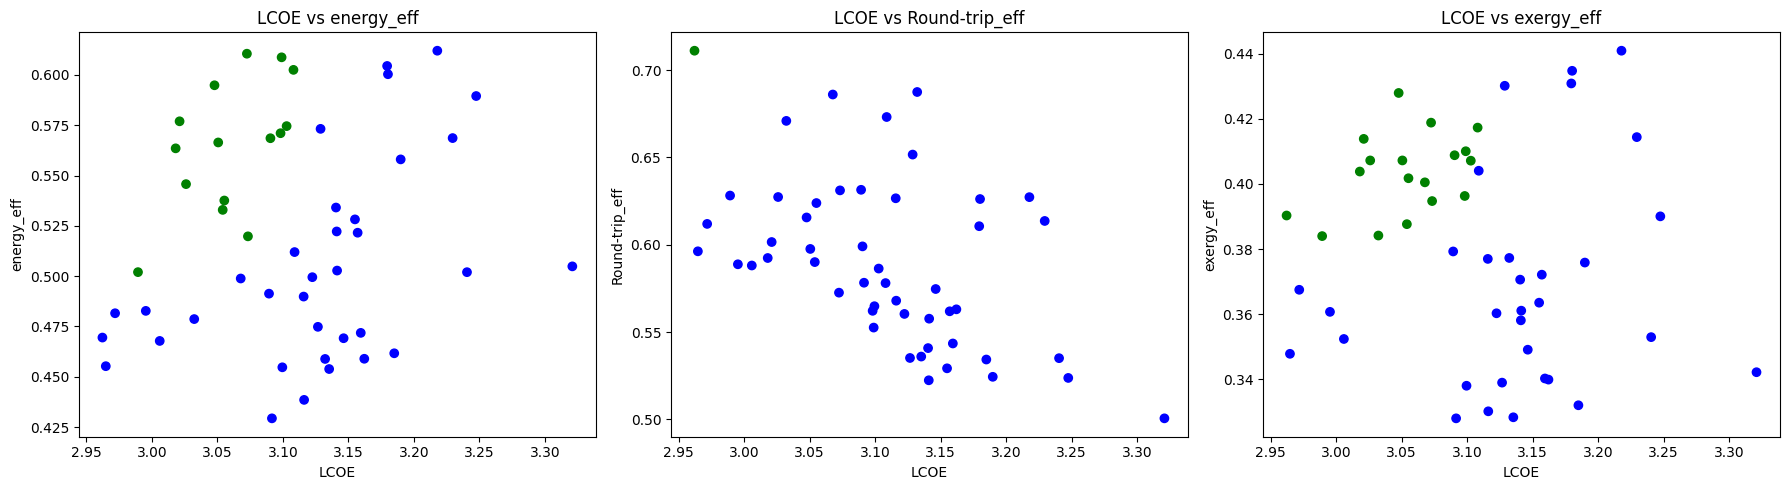

In [9]:
data = [
    {'min_temperature_exchange': 27.343748475098767, 'industrial_waste_heat_t': 277.2444125646536, 'p_bray_H': 18773480.803443152, 'p_bray_H_B': 28374839.3715854, 'Round-trip_eff': np.float64(0.5224265096895391), 'energy_eff': np.float64(0.5222049018620787), 'exergy_eff': np.float64(0.3580823899643107), 'LCOE': np.float64(3.141005377935851)},
    {'min_temperature_exchange': 23.530714389096204, 'industrial_waste_heat_t': 299.2518644611018, 'p_bray_H': 18924952.2525061, 'p_bray_H_B': 25031724.89796488, 'Round-trip_eff': np.float64(0.5962787524949699), 'energy_eff': np.float64(0.45527032716305826), 'exergy_eff': np.float64(0.3477913402291074), 'LCOE': np.float64(2.9647404802443624)},
    {'min_temperature_exchange': 17.33061887700574, 'industrial_waste_heat_t': 267.0478060468389, 'p_bray_H': 18855023.229886457, 'p_bray_H_B': 27466440.463990226, 'Round-trip_eff': np.float64(0.5924391992003673), 'energy_eff': np.float64(0.5635010085481587), 'exergy_eff': np.float64(0.40382497985091975), 'LCOE': np.float64(3.0180658136763063)},
    {'min_temperature_exchange': 19.291068434271, 'industrial_waste_heat_t': 261.77692018386455, 'p_bray_H': 18059256.44319783, 'p_bray_H_B': 28115237.62333779, 'Round-trip_eff': np.float64(0.5621952283725407), 'energy_eff': np.float64(0.5710155843482184), 'exergy_eff': np.float64(0.396311133059321), 'LCOE': np.float64(3.098149139753781)},
    {'min_temperature_exchange': 12.263899174020459, 'industrial_waste_heat_t': 251.26520535888505, 'p_bray_H': 17467747.39343022, 'p_bray_H_B': 25766287.422360025, 'Round-trip_eff': np.float64(0.6106480917309399), 'energy_eff': np.float64(0.6044290334069402), 'exergy_eff': np.float64(0.43090370717561527), 'LCOE': np.float64(3.179505810773062)},
    {'min_temperature_exchange': 12.803172770302556, 'industrial_waste_heat_t': 287.8135945722273, 'p_bray_H': 17237380.352813177, 'p_bray_H_B': 28157822.864919435, 'Round-trip_eff': np.float64(0.6709503792151534), 'energy_eff': np.float64(0.4786736962206654), 'exergy_eff': np.float64(0.3841511571258809), 'LCOE': np.float64(3.0322459504141515)},
    {'min_temperature_exchange': 25.103393611149148, 'industrial_waste_heat_t': 269.90709892114836, 'p_bray_H': 18068056.46485152, 'p_bray_H_B': 25136978.20508523, 'Round-trip_eff': np.float64(0.5292795997808059), 'energy_eff': np.float64(0.5282059951945991), 'exergy_eff': np.float64(0.3635068014349777), 'LCOE': np.float64(3.1549546026635884)},
    {'min_temperature_exchange': 14.205049354066734, 'industrial_waste_heat_t': 270.5314004148535, 'p_bray_H': 18311608.797464766, 'p_bray_H_B': 27225647.874980856, 'Round-trip_eff': np.float64(0.6273652478927977), 'energy_eff': np.float64(0.5457267594493296), 'exergy_eff': np.float64(0.40723704341581296), 'LCOE': np.float64(3.0259928572038324)},
    {'min_temperature_exchange': 12.159532971095715, 'industrial_waste_heat_t': 258.6532173258944, 'p_bray_H': 16538840.639698122, 'p_bray_H_B': 29883001.736457266, 'Round-trip_eff': np.float64(0.6136505350094903), 'energy_eff': np.float64(0.5686012820608671), 'exergy_eff': np.float64(0.41440798081838787), 'LCOE': np.float64(3.2295088687071596)},
    {'min_temperature_exchange': 16.103211024165816, 'industrial_waste_heat_t': 260.7059242620339, 'p_bray_H': 17716916.118533492, 'p_bray_H_B': 28764152.105935354, 'Round-trip_eff': np.float64(0.5863971117850189), 'energy_eff': np.float64(0.5745430986999621), 'exergy_eff': np.float64(0.4071615743628041), 'LCOE': np.float64(3.1027820267157615)},
    {'min_temperature_exchange': 28.18598146709479, 'industrial_waste_heat_t': 290.1966906833392, 'p_bray_H': 18364217.121967155, 'p_bray_H_B': 27165845.166474633, 'Round-trip_eff': np.float64(0.5351998561380471), 'energy_eff': np.float64(0.4748182846346965), 'exergy_eff': np.float64(0.33892965250398394), 'LCOE': np.float64(3.1266654809845185)},
    {'min_temperature_exchange': 15.029306921025157, 'industrial_waste_heat_t': 278.3854138845278, 'p_bray_H': 16694597.631504258, 'p_bray_H_B': 26444397.28333317, 'Round-trip_eff': np.float64(0.631489258201247), 'energy_eff': np.float64(0.4913033768864378), 'exergy_eff': np.float64(0.3792567843784761), 'LCOE': np.float64(3.0893332681646846)},
    {'min_temperature_exchange': 18.0654000832375, 'industrial_waste_heat_t': 271.9667352248444, 'p_bray_H': 17832529.2558927, 'p_bray_H_B': 28360710.91691035, 'Round-trip_eff': np.float64(0.5901069162237911), 'energy_eff': np.float64(0.5329258233300296), 'exergy_eff': np.float64(0.3876441666841957), 'LCOE': np.float64(3.0539884627829266)},
    {'min_temperature_exchange': 20.814843360052137, 'industrial_waste_heat_t': 252.3151308676226, 'p_bray_H': 16813755.542204987, 'p_bray_H_B': 29915189.34435192, 'Round-trip_eff': np.float64(0.5237724448007284), 'energy_eff': np.float64(0.5894922599043403), 'exergy_eff': np.float64(0.3900475668582719), 'LCOE': np.float64(3.247478797732295)},
    {'min_temperature_exchange': 26.57093885755494, 'industrial_waste_heat_t': 288.1085327829743, 'p_bray_H': 16880751.027723726, 'p_bray_H_B': 28738218.196436264, 'Round-trip_eff': np.float64(0.5343151821607313), 'energy_eff': np.float64(0.4616747568747677), 'exergy_eff': np.float64(0.33197199258848314), 'LCOE': np.float64(3.184934468790122)},
    {'min_temperature_exchange': 11.006763640269849, 'industrial_waste_heat_t': 275.8517631988971, 'p_bray_H': 17439363.95955745, 'p_bray_H_B': 25318206.49246437, 'Round-trip_eff': np.float64(0.673168113175422), 'energy_eff': np.float64(0.5119607831178091), 'exergy_eff': np.float64(0.40406776445751713), 'LCOE': np.float64(3.1088543184407604)},
    {'min_temperature_exchange': 22.721822720513103, 'industrial_waste_heat_t': 294.3959020270801, 'p_bray_H': 18199758.23926566, 'p_bray_H_B': 28471924.503736112, 'Round-trip_eff': np.float64(0.5881497857381587), 'energy_eff': np.float64(0.4678107049463953), 'exergy_eff': np.float64(0.35235010866544647), 'LCOE': np.float64(3.00591050533797)},
    {'min_temperature_exchange': 19.460009464239253, 'industrial_waste_heat_t': 291.58160319175016, 'p_bray_H': 18311874.86391118, 'p_bray_H_B': 29460299.617230527, 'Round-trip_eff': np.float64(0.6119629848366013), 'energy_eff': np.float64(0.4815677447645604), 'exergy_eff': np.float64(0.36747272391124863), 'LCOE': np.float64(2.9718262921026795)},
    {'min_temperature_exchange': 21.74712219657522, 'industrial_waste_heat_t': 275.89878062892984, 'p_bray_H': 16912415.461296804, 'p_bray_H_B': 29017409.335330475, 'Round-trip_eff': np.float64(0.5576933160327274), 'energy_eff': np.float64(0.5027707983894879), 'exergy_eff': np.float64(0.3610535074343039), 'LCOE': np.float64(3.141304970939524)},
    {'min_temperature_exchange': 10.37974717287183, 'industrial_waste_heat_t': 262.836052887032, 'p_bray_H': 18202064.799943756, 'p_bray_H_B': 26328273.21423955, 'Round-trip_eff': np.float64(0.6516641891727534), 'energy_eff': np.float64(0.5731817459483479), 'exergy_eff': np.float64(0.43018703823883503), 'LCOE': np.float64(3.128692983220449)},
    {'min_temperature_exchange': 16.091719626952816, 'industrial_waste_heat_t': 264.26622780751643, 'p_bray_H': 18300932.744873505, 'p_bray_H_B': 27329360.96752666, 'Round-trip_eff': np.float64(0.5976301666344561), 'energy_eff': np.float64(0.5664249975918749), 'exergy_eff': np.float64(0.40723522774342147), 'LCOE': np.float64(3.0505576409221806)},
    {'min_temperature_exchange': 22.092810444286094, 'industrial_waste_heat_t': 285.5422095551885, 'p_bray_H': 16035060.327090131, 'p_bray_H_B': 29956383.057439115, 'Round-trip_eff': np.float64(0.5630544101989422), 'energy_eff': np.float64(0.4589492017570618), 'exergy_eff': np.float64(0.3398588423451718), 'LCOE': np.float64(3.162071899594478)},
    {'min_temperature_exchange': 10.808461795621868, 'industrial_waste_heat_t': 256.3680861301265, 'p_bray_H': 17778809.016762353, 'p_bray_H_B': 29331449.40451979, 'Round-trip_eff': np.float64(0.6262065691367055), 'energy_eff': np.float64(0.6003279899528475), 'exergy_eff': np.float64(0.4347897787491942), 'LCOE': np.float64(3.180141853398607)},
    {'min_temperature_exchange': 10.927095875432226, 'industrial_waste_heat_t': 299.5772399514571, 'p_bray_H': 18429468.771241583, 'p_bray_H_B': 29976583.410780698, 'Round-trip_eff': np.float64(0.711128432456501), 'energy_eff': np.float64(0.46948780878366303), 'exergy_eff': np.float64(0.3903076274385308), 'LCOE': np.float64(2.9621573328400537)},
    {'min_temperature_exchange': 13.185721066872961, 'industrial_waste_heat_t': 261.56161107625655, 'p_bray_H': 18974671.19105732, 'p_bray_H_B': 29279423.7296936, 'Round-trip_eff': np.float64(0.615652954163443), 'energy_eff': np.float64(0.594839546424333), 'exergy_eff': np.float64(0.42797873625378346), 'LCOE': np.float64(3.0477213961742065)},
    {'min_temperature_exchange': 22.76693333994931, 'industrial_waste_heat_t': 268.71634228326735, 'p_bray_H': 16092997.575654816, 'p_bray_H_B': 25756833.0921818, 'Round-trip_eff': np.float64(0.535085882411313), 'energy_eff': np.float64(0.5019753208796814), 'exergy_eff': np.float64(0.3529157027543735), 'LCOE': np.float64(3.240469611751098)},
    {'min_temperature_exchange': 19.2773264740157, 'industrial_waste_heat_t': 253.77972533611927, 'p_bray_H': 18706133.082071424, 'p_bray_H_B': 26816085.012106605, 'Round-trip_eff': np.float64(0.5526035413052831), 'energy_eff': np.float64(0.6087227852385997), 'exergy_eff': np.float64(0.4100661251051567), 'LCOE': np.float64(3.0989452419914296)},
    {'min_temperature_exchange': 23.60499201083043, 'industrial_waste_heat_t': 296.0615945516183, 'p_bray_H': 16661007.458306108, 'p_bray_H_B': 24581506.92911325, 'Round-trip_eff': np.float64(0.578282854830311), 'energy_eff': np.float64(0.42935194829145196), 'exergy_eff': np.float64(0.3279521416481168), 'LCOE': np.float64(3.0915697249267673)},
    {'min_temperature_exchange': 10.871272373007024, 'industrial_waste_heat_t': 282.0633729097029, 'p_bray_H': 17705246.643879846, 'p_bray_H_B': 26002791.501733914, 'Round-trip_eff': np.float64(0.6860506920226105), 'energy_eff': np.float64(0.49883350182479747), 'exergy_eff': np.float64(0.4005018995572629), 'LCOE': np.float64(3.067735573977262)},
    {'min_temperature_exchange': 19.85378759525012, 'industrial_waste_heat_t': 269.92751597678296, 'p_bray_H': 16685687.005052134, 'p_bray_H_B': 29833917.089174777, 'Round-trip_eff': np.float64(0.5619275818617308), 'energy_eff': np.float64(0.5215806524233482), 'exergy_eff': np.float64(0.3721175482859313), 'LCOE': np.float64(3.156997546659759)},
    {'min_temperature_exchange': 25.24961962992318, 'industrial_waste_heat_t': 282.3758402179689, 'p_bray_H': 17183557.27950879, 'p_bray_H_B': 24022881.268876683, 'Round-trip_eff': np.float64(0.5435044895817567), 'energy_eff': np.float64(0.47181760680421964), 'exergy_eff': np.float64(0.3402094950120538), 'LCOE': np.float64(3.159378309398445)},
    {'min_temperature_exchange': 24.018870687476614, 'industrial_waste_heat_t': 290.37928502652824, 'p_bray_H': 16966684.878928073, 'p_bray_H_B': 26787764.980330758, 'Round-trip_eff': np.float64(0.5648401001593663), 'energy_eff': np.float64(0.4547082384873309), 'exergy_eff': np.float64(0.3379710894782374), 'LCOE': np.float64(3.099510248073266)},
    {'min_temperature_exchange': 16.378998898763072, 'industrial_waste_heat_t': 281.53668968751117, 'p_bray_H': 18048015.633508775, 'p_bray_H_B': 26460066.01690999, 'Round-trip_eff': np.float64(0.6281939318751971), 'energy_eff': np.float64(0.5019986052728327), 'exergy_eff': np.float64(0.3839785559698754), 'LCOE': np.float64(2.989315097171224)},
    {'min_temperature_exchange': 15.710443875618507, 'industrial_waste_heat_t': 264.41474867396016, 'p_bray_H': 18940638.094953384, 'p_bray_H_B': 27829971.457464013, 'Round-trip_eff': np.float64(0.6015885732610055), 'energy_eff': np.float64(0.576936772835247), 'exergy_eff': np.float64(0.413863814572862), 'LCOE': np.float64(3.0210657841997475)},
    {'min_temperature_exchange': 14.291354442305801, 'industrial_waste_heat_t': 271.5935272561317, 'p_bray_H': 17347384.498454668, 'p_bray_H_B': 24856916.463683028, 'Round-trip_eff': np.float64(0.6311615741704348), 'energy_eff': np.float64(0.519778416026783), 'exergy_eff': np.float64(0.3947487293918377), 'LCOE': np.float64(3.0732510819240972)},
    {'min_temperature_exchange': 15.475244752010152, 'industrial_waste_heat_t': 259.6329028392755, 'p_bray_H': 17913856.859232783, 'p_bray_H_B': 24363860.975605037, 'Round-trip_eff': np.float64(0.5990976933400294), 'energy_eff': np.float64(0.5685262489242409), 'exergy_eff': np.float64(0.40883538707305905), 'LCOE': np.float64(3.09041368925485)},
    {'min_temperature_exchange': 22.072926841280882, 'industrial_waste_heat_t': 275.9903648761091, 'p_bray_H': 17135605.73253616, 'p_bray_H_B': 26255904.310366884, 'Round-trip_eff': np.float64(0.5604205933019077), 'energy_eff': np.float64(0.4994863542895168), 'exergy_eff': np.float64(0.3602483093935017), 'LCOE': np.float64(3.1224117755229717)},
    {'min_temperature_exchange': 23.59138591070306, 'industrial_waste_heat_t': 294.2916440561078, 'p_bray_H': 16361242.900363952, 'p_bray_H_B': 28906408.64650696, 'Round-trip_eff': np.float64(0.5679934087435287), 'energy_eff': np.float64(0.4385224030071591), 'exergy_eff': np.float64(0.3301150902462109), 'LCOE': np.float64(3.116128462521358)},
    {'min_temperature_exchange': 23.524484056830893, 'industrial_waste_heat_t': 260.9968817425624, 'p_bray_H': 17588626.918525428, 'p_bray_H_B': 26598033.779194243, 'Round-trip_eff': np.float64(0.5244137858467142), 'energy_eff': np.float64(0.5580105637257657), 'exergy_eff': np.float64(0.3758434797937542), 'LCOE': np.float64(3.18984891311632)},
    {'min_temperature_exchange': 20.552645392371613, 'industrial_waste_heat_t': 279.59014898826376, 'p_bray_H': 16045422.766152937, 'p_bray_H_B': 25842081.1436906, 'Round-trip_eff': np.float64(0.5746862073982246), 'energy_eff': np.float64(0.4691588118064086), 'exergy_eff': np.float64(0.34905098995962774), 'LCOE': np.float64(3.1462783400597716)},
    {'min_temperature_exchange': 14.977916202326627, 'industrial_waste_heat_t': 276.87025454617645, 'p_bray_H': 16293297.361177752, 'p_bray_H_B': 26823297.83396211, 'Round-trip_eff': np.float64(0.6266388550304842), 'energy_eff': np.float64(0.4898545398902206), 'exergy_eff': np.float64(0.3769669476211473), 'LCOE': np.float64(3.11577894929126)},
    {'min_temperature_exchange': 14.58688083149614, 'industrial_waste_heat_t': 268.40973783831714, 'p_bray_H': 17883761.622464195, 'p_bray_H_B': 24567282.591968074, 'Round-trip_eff': np.float64(0.6239069618051889), 'energy_eff': np.float64(0.5375803398631115), 'exergy_eff': np.float64(0.401765127354724), 'LCOE': np.float64(3.055214344846877)},
    {'min_temperature_exchange': 17.07378994988032, 'industrial_waste_heat_t': 254.5334175391611, 'p_bray_H': 18811914.267194957, 'p_bray_H_B': 27149305.045018215, 'Round-trip_eff': np.float64(0.5725962478576516), 'energy_eff': np.float64(0.61051928656817), 'exergy_eff': np.float64(0.41885462940408724), 'LCOE': np.float64(3.0724573013752843)},
    {'min_temperature_exchange': 10.081326665064534, 'industrial_waste_heat_t': 253.90381275790077, 'p_bray_H': 17754766.054110985, 'p_bray_H_B': 29667831.476989385, 'Round-trip_eff': np.float64(0.6272870305488529), 'energy_eff': np.float64(0.6120059337383572), 'exergy_eff': np.float64(0.4409673888493325), 'LCOE': np.float64(3.217812152297907)},
    {'min_temperature_exchange': 11.351057358238252, 'industrial_waste_heat_t': 287.03422683514003, 'p_bray_H': 16149813.32652948, 'p_bray_H_B': 26116910.159438092, 'Round-trip_eff': np.float64(0.6874918998234438), 'energy_eff': np.float64(0.45886100372963096), 'exergy_eff': np.float64(0.3772587987043285), 'LCOE': np.float64(3.1321619458079875)},
    {'min_temperature_exchange': 16.173401778232822, 'industrial_waste_heat_t': 253.80159517311512, 'p_bray_H': 18074373.619668197, 'p_bray_H_B': 26843297.79061267, 'Round-trip_eff': np.float64(0.5780830477341106), 'energy_eff': np.float64(0.6024896366902974), 'exergy_eff': np.float64(0.4173310328880954), 'LCOE': np.float64(3.1080015004409414)},
    {'min_temperature_exchange': 22.13836743353381, 'industrial_waste_heat_t': 290.44286442518376, 'p_bray_H': 18548281.78037508, 'p_bray_H_B': 27964374.21631225, 'Round-trip_eff': np.float64(0.5888466064205415), 'energy_eff': np.float64(0.482744830608349), 'exergy_eff': np.float64(0.36068745937571023), 'LCOE': np.float64(2.995283333091983)},
    {'min_temperature_exchange': 26.416405272744935, 'industrial_waste_heat_t': 269.36287340808445, 'p_bray_H': 16199342.856820788, 'p_bray_H_B': 28393921.09364167, 'Round-trip_eff': np.float64(0.5006345004870736), 'energy_eff': np.float64(0.5048610296177787), 'exergy_eff': np.float64(0.3421324202327876), 'LCOE': np.float64(3.3208920937716493)},
    {'min_temperature_exchange': 23.185095386414154, 'industrial_waste_heat_t': 267.16543930197037, 'p_bray_H': 17860181.22549887, 'p_bray_H_B': 24611835.86072588, 'Round-trip_eff': np.float64(0.540861258820133), 'energy_eff': np.float64(0.5340899517336652), 'exergy_eff': np.float64(0.3705913234690726), 'LCOE': np.float64(3.140464201509888)},
    {'min_temperature_exchange': 28.999236658453743, 'industrial_waste_heat_t': 296.46126565627804, 'p_bray_H': 18056435.391496312, 'p_bray_H_B': 27418261.958625615, 'Round-trip_eff': np.float64(0.5360086239293406), 'energy_eff': np.float64(0.45385459495680547), 'exergy_eff': np.float64(0.32827554874835296), 'LCOE': np.float64(3.1352505458377635)},
]
# 提取数据
lcoe_values = [d['LCOE'] for d in data]
energy_eff_values = [d['energy_eff'] for d in data]
round_trip_eff_values = [d['Round-trip_eff'] for d in data]
exergy_eff_values = [d['exergy_eff'] for d in data]
 
# 设置颜色阈值（可选，根据数据分布调整）
lcoe_threshold = np.median(lcoe_values)  # LCOE的中位数作为阈值
efficiency_threshold = 0.5  # 效率值的阈值，可根据实际情况调整
 
# 绘制散点图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# LCOE vs energy_eff
colors = ['green' if lcoe < lcoe_threshold and eff > efficiency_threshold else 'blue' for lcoe, eff in zip(lcoe_values, energy_eff_values)]
axes[0].scatter(lcoe_values, energy_eff_values, c=colors)
axes[0].set_title('LCOE vs energy_eff')
axes[0].set_xlabel('LCOE')
axes[0].set_ylabel('energy_eff')
 
# LCOE vs Round-trip_eff
colors = ['green' if lcoe < lcoe_threshold and eff > 0.7 else 'blue' for lcoe, eff in zip(lcoe_values, round_trip_eff_values)]
axes[1].scatter(lcoe_values, round_trip_eff_values, c=colors)
axes[1].set_title('LCOE vs Round-trip_eff')
axes[1].set_xlabel('LCOE')
axes[1].set_ylabel('Round-trip_eff')
 
# LCOE vs exergy_eff
colors = ['green' if lcoe < lcoe_threshold and eff > 0.38 else 'blue' for lcoe, eff in zip(lcoe_values, exergy_eff_values)]
axes[2].scatter(lcoe_values, exergy_eff_values, c=colors)
axes[2].set_title('LCOE vs exergy_eff')
axes[2].set_xlabel('LCOE')
axes[2].set_ylabel('exergy_eff')
 
# 调整布局并显示图表
plt.tight_layout()
plt.show()

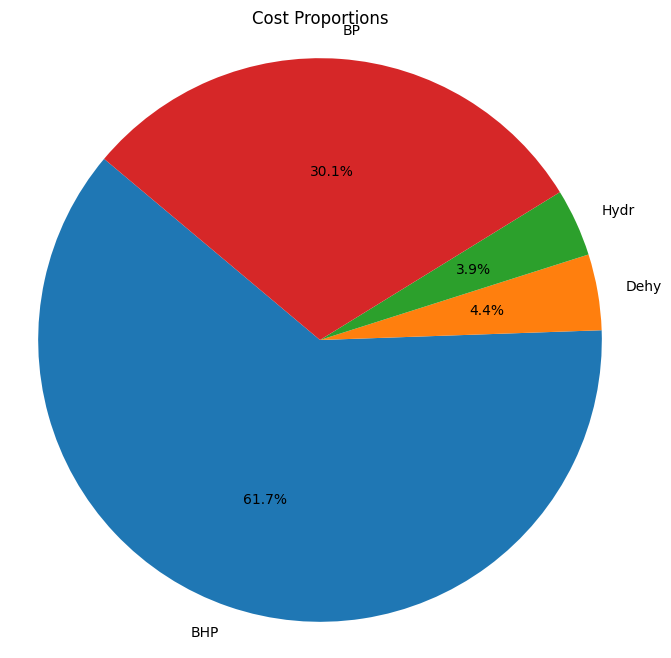

In [10]:
import matplotlib.pyplot as plt
 
# 定义各部分成本
cost_BHP = 1003471605.3439078
cost_Dehy = 70878496.17499264
cost_Hydr = 63205536.27754139
cost_BP = 489798002.0225979
 
# 计算总成本
total_cost = cost_BHP + cost_Dehy + cost_Hydr + cost_BP
 
# 计算各部分成本的比例
proportions = [cost_BHP / total_cost, cost_Dehy / total_cost, cost_Hydr / total_cost, cost_BP / total_cost]
 
# 定义标签
labels = ['BHP', 'Dehy', 'Hydr', 'BP']
 
# 绘制饼图
plt.figure(figsize=(8, 8))  # 设置图表大小
plt.pie(proportions, labels=labels, autopct='%1.1f%%', startangle=140)  # autopct显示百分比，startangle设置起始角度
plt.title('Cost Proportions')  # 设置图表标题
plt.axis('equal')  # 确保饼图是圆形的
plt.show()  # 显示图表

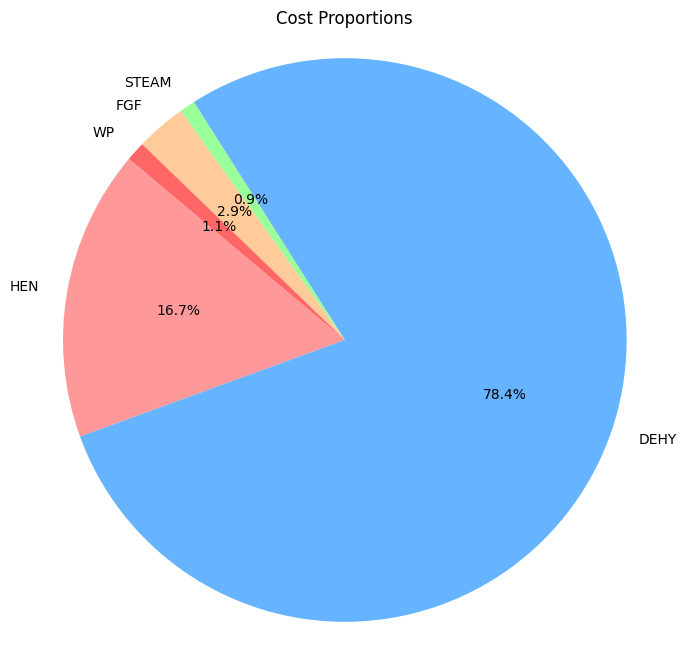

In [11]:
# 定义各部分成本
cost_hen = 11821286.56823872
cost_dehy = 55591347.03860855
cost_steam = 631656.7059926675
cost_fgf = 2043015.1248274834
cost_wp = 791190.7373252093
 
# 计算总成本
total_cost = cost_hen + cost_dehy + cost_steam + cost_fgf + cost_wp
 
# 计算各部分成本的比例
proportions = [cost_hen / total_cost, cost_dehy / total_cost, cost_steam / total_cost, cost_fgf / total_cost, cost_wp / total_cost]
 
# 定义标签
labels = ['HEN', 'DEHY', 'STEAM', 'FGF', 'WP']
 
# 绘制饼图
plt.figure(figsize=(8, 8))  # 设置图表大小
plt.pie(proportions, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#ff6666'])  # 添加颜色
plt.title('Cost Proportions')  # 设置图表标题
plt.axis('equal')  # 确保饼图是圆形的
plt.show()  # 显示图表

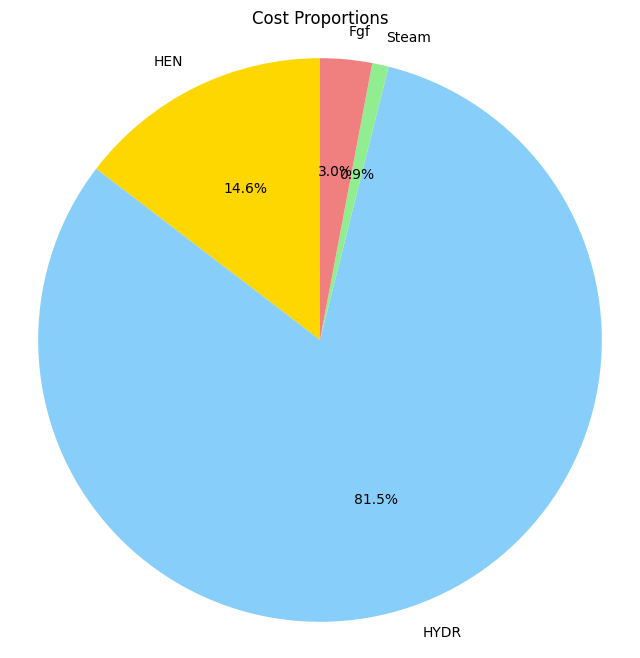

In [12]:
# 定义各部分成本
cost_HEN = 9233675.021726942
cost_hydr = 51495967.5397114
cost_Steam = 597479.9793011758
cost_Fgf = 1878413.7368018678
 
# 计算总成本
total_cost = cost_HEN + cost_hydr + cost_Steam + cost_Fgf
 
# 计算各部分成本的比例
proportions = [cost_HEN / total_cost, cost_hydr / total_cost, cost_Steam / total_cost, cost_Fgf / total_cost]
 
# 定义标签
labels = ['HEN', 'HYDR', 'Steam', 'Fgf']
 
# 绘制饼图
plt.figure(figsize=(8, 8))  # 设置图表大小
plt.pie(proportions, labels=labels, autopct='%1.1f%%', startangle=90, colors=['gold', 'lightskyblue', 'lightgreen', 'lightcoral'])  # 添加颜色并设置起始角度
plt.title('Cost Proportions')  # 设置图表标题
plt.axis('equal')  # 确保饼图是圆形的
plt.show()  # 显示图表

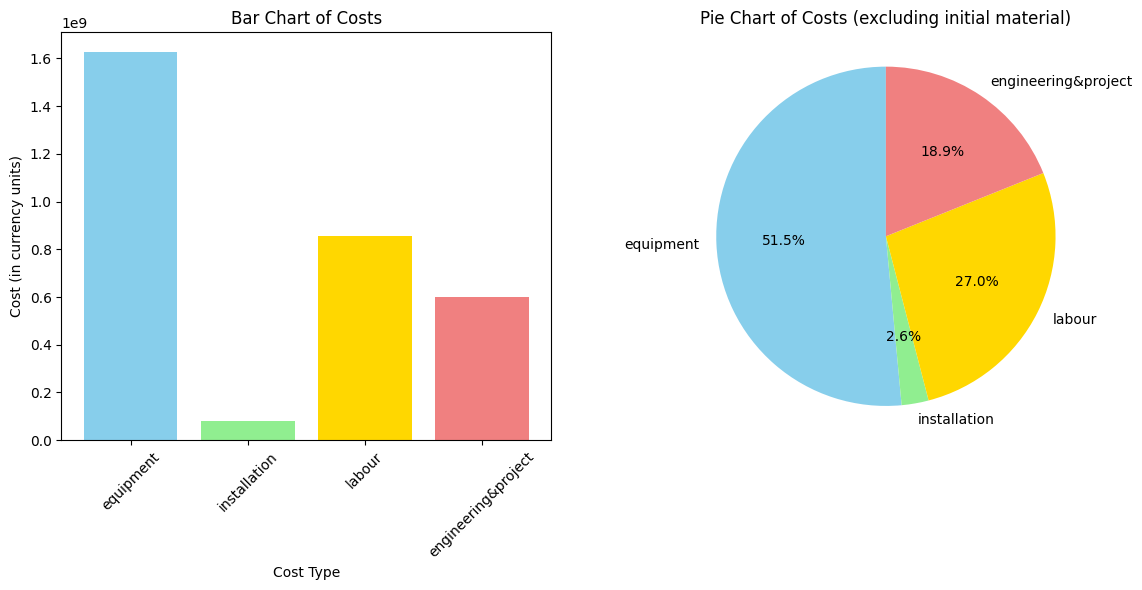

In [13]:
# 定义各项成本数据
data = {
    "equipment": 1627353639.8190396,
    "installation": 81367681.99095199,
    "labour": 854360660.9049958,
    "engineering&project": 598052462.633497,
    "initial_material": 2.5891668231995633
}
 
# 提取数据标签
labels = list(data.keys())
 
# 提取成本数值
values = list(data.values())
 
# 由于initial_material的值非常小，为了更清晰地展示其他部分的占比，
# 我们可以选择将其从饼图中省略（但在柱状图中保留），或者将其合并到其他类别中。
# 在此示例中，我们选择在饼图中省略它，但会在柱状图中展示。
# 若要在饼图中包含它，请确保不对values进行切片操作。
values_for_pie = values[:-1]  # 省略initial_material
 
# 绘制柱状图
plt.figure(figsize=(12, 6))  # 设定图表尺寸
 
# 绘制柱状图的第一部分（前四项）
plt.subplot(1, 2, 1)  # 在1行2列的布局中选择第一个子图
plt.bar(labels[:-1], values[:-1], color=['skyblue', 'lightgreen', 'gold', 'lightcoral'])  # 绘制柱状图，并指定颜色
plt.xlabel('Cost Type')  # 设置x轴标签
plt.ylabel('Cost (in currency units)')  # 设置y轴标签（请根据实际情况替换货币单位）
plt.title('Bar Chart of Costs')  # 设置图表标题
plt.xticks(rotation=45)  # 旋转x轴标签，以便更清晰地展示
 
# 绘制饼图
plt.subplot(1, 2, 2)  # 在1行2列的布局中选择第二个子图
plt.pie(values_for_pie, labels=labels[:-1], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen', 'gold', 'lightcoral'])  # 绘制饼图，并设置颜色、标签、百分比显示格式及起始角度
plt.title('Pie Chart of Costs (excluding initial material)')  # 设置图表标题（注意已省略initial_material）
plt.axis('equal')  # 确保饼图为圆形
 
# 若要在饼图中包含initial_material（尽管其占比很小），请使用以下代码替换plt.pie行：
# 注意：这样做可能会使饼图中的其他部分看起来非常接近或重叠。
# plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen', 'gold', 'lightcoral', 'gray'])
 
# 展示图表
plt.tight_layout()  # 自动调整子图参数，使之填充整个图表区域
plt.show()  # 展示图表

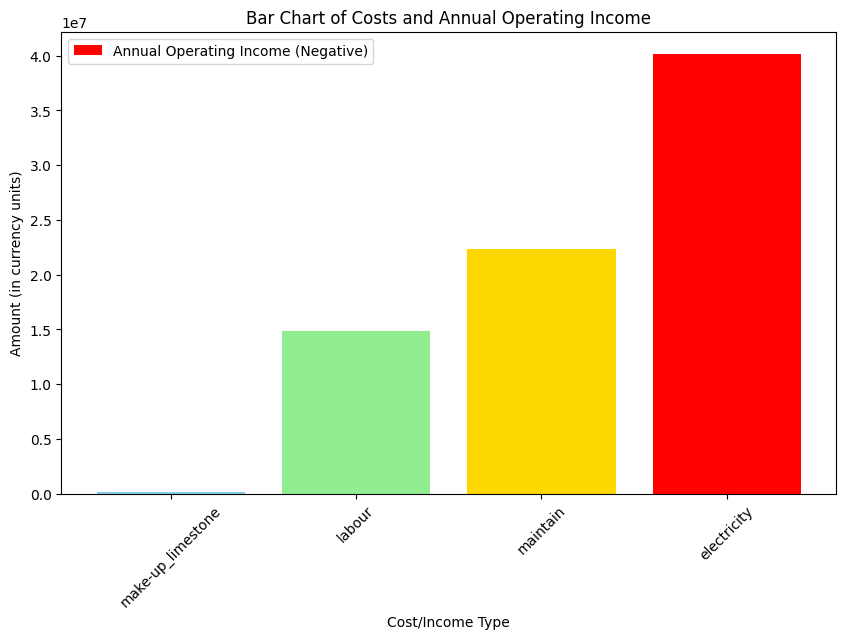

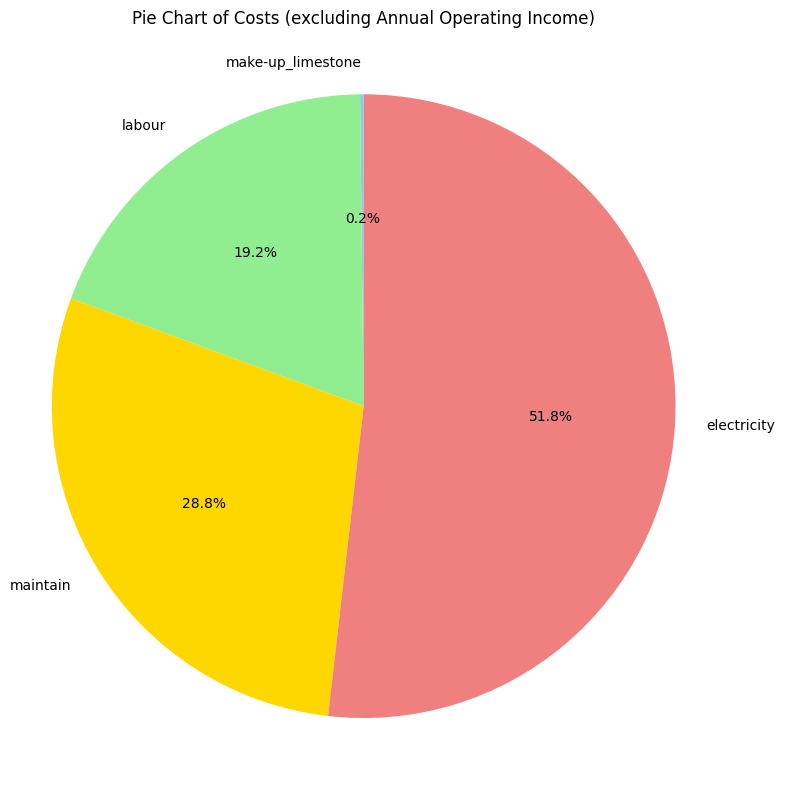

In [14]:
# 定义各项成本及收入数据
data = {
    "make-up_limestone": 143842.60128886462,
    "labour": 14883674.690970639,
    "maintain": 22325512.03645596,
    "electricity": 40178532.67704905,
    "Annual_operating_income": -140472434.20930108  # 注意：此为负值收入，将在饼图中被排除
}
 
# 提取数据标签（排除Annual_operating_income）
labels = list(data.keys())[:-1]
 
# 提取成本及费用数值（排除Annual_operating_income）
values = list(data.values())[:-1]
 
# 若要在图表中突出显示负值的年度运营收入（仅在柱状图中），我们可以将其单独处理
income_label = labels[-1]
income_value = values[-1]
 
# 绘制柱状图
plt.figure(figsize=(10, 6))  # 设定图表尺寸
plt.bar(labels, values, color=['skyblue', 'lightgreen', 'gold', 'lightcoral'])  # 绘制柱状图，并指定颜色
plt.bar(income_label, income_value, color='red', label='Annual Operating Income (Negative)')  # 单独绘制年度运营收入，并指定为红色及标签
plt.xlabel('Cost/Income Type')  # 设置x轴标签
plt.ylabel('Amount (in currency units)')  # 设置y轴标签（请根据实际情况替换货币单位）
plt.title('Bar Chart of Costs and Annual Operating Income')  # 设置图表标题
plt.xticks(rotation=45)  # 旋转x轴标签，以便更清晰地展示
plt.legend()  # 显示图例
 
# 绘制饼图（排除Annual_operating_income）
plt.figure(figsize=(8, 8))  # 设定图表尺寸
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen', 'gold', 'lightcoral'])  # 绘制饼图，并设置颜色、标签、百分比显示格式及起始角度
plt.title('Pie Chart of Costs (excluding Annual Operating Income)')  # 设置图表标题
plt.axis('equal')  # 确保饼图为圆形
 
# 展示图表
plt.tight_layout()  # 自动调整子图参数（虽然此处只有一个图表，但仍是好习惯）
plt.show()  # 展示图表

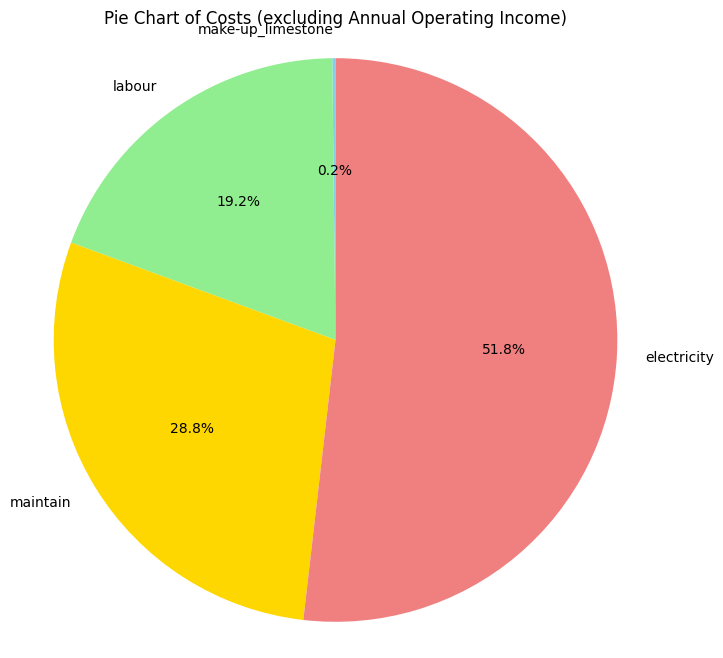

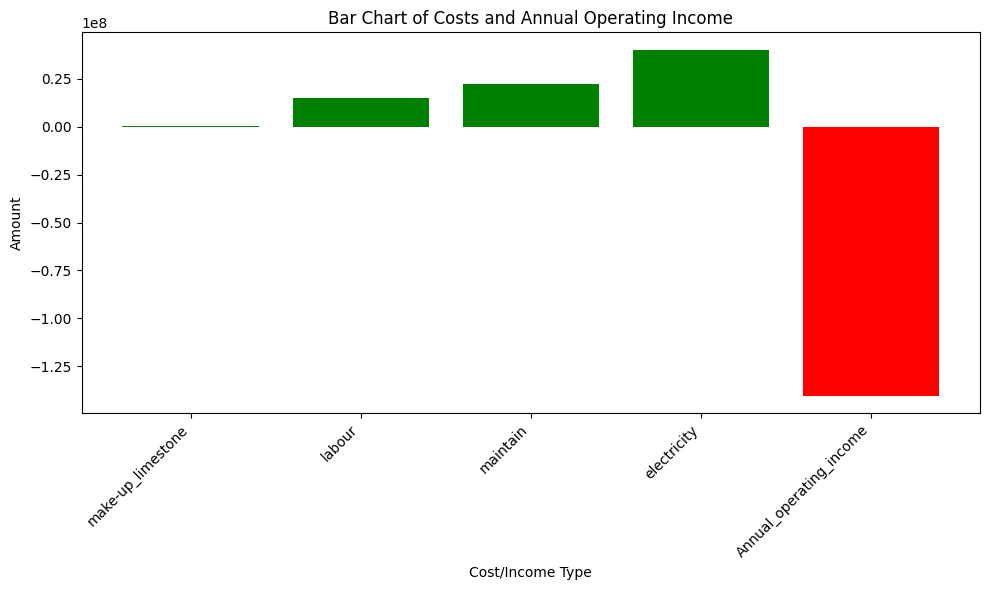

In [16]:
# 数据
data = {
    "make-up_limestone": 143842.60128886462,
    "labour": 14883674.690970639,
    "maintain": 22325512.03645596,
    "electricity": 40178532.67704905,
    "Annual_operating_income": -140472434.20930108,
}
 
# 饼状图数据（前四项）
pie_labels = list(data.keys())[:4]
pie_values = list(data.values())[:4]
 
# 柱状图数据（前五项）
bar_labels = list(data.keys())
bar_values = list(data.values())
 
# 为了在柱状图中区分收入和支出，我们可以设置颜色
# 假设所有正数都是支出（绿色），负数都是收入（红色）
bar_colors = ['green' if v > 0 else 'red' for v in bar_values]
 
# 绘制饼状图
plt.figure(figsize=(8, 8))
plt.pie(pie_values, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen', 'gold', 'lightcoral'])
plt.title('Pie Chart of Costs (excluding Annual Operating Income)')
plt.axis('equal')  # 确保饼图为圆形
 
# 绘制柱状图
plt.figure(figsize=(10, 6))
plt.bar(bar_labels, bar_values, color=bar_colors)
plt.xlabel('Cost/Income Type')
plt.ylabel('Amount')
plt.title('Bar Chart of Costs and Annual Operating Income')
plt.xticks(rotation=45, ha='right')  # 旋转x轴标签并右对齐，以便更清晰地展示
 
# 展示图表
plt.tight_layout()
plt.show()

The best front for Generation number  0  is
5.521 -5.075 

The best front for Generation number  1  is
-2.018 5.521 

The best front for Generation number  2  is
5.521 -2.018 

The best front for Generation number  3  is
0.557 

The best front for Generation number  4  is
-0.041 0.557 

The best front for Generation number  5  is
0.355 -0.041 0.557 

The best front for Generation number  6  is
0.557 0.355 -0.041 

The best front for Generation number  7  is
-0.041 0.557 0.355 

The best front for Generation number  8  is
0.355 -0.041 0.557 

The best front for Generation number  9  is
2.413 0.355 -0.041 0.557 

The best front for Generation number  10  is
0.557 2.413 0.355 -0.041 

The best front for Generation number  11  is
-0.041 0.557 2.413 0.355 

The best front for Generation number  12  is
0.355 -0.041 0.557 2.413 

The best front for Generation number  13  is
2.413 0.355 -0.041 0.557 

The best front for Generation number  14  is
1.23 2.413 0.355 -0.041 0.557 

The best front f

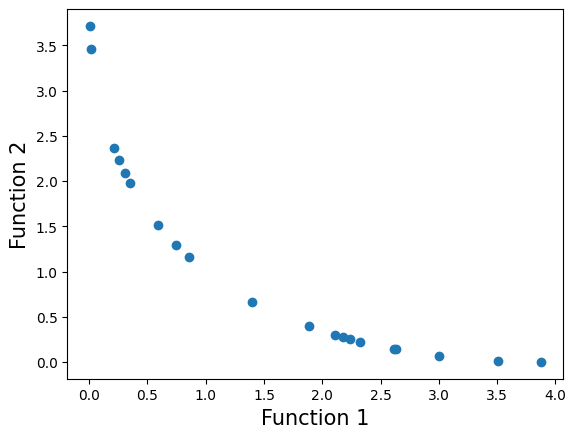

In [1]:
import math
import random
import matplotlib.pyplot as plt

#First function to optimize
def function1(x):
    value = -x**2
    return value

#Second function to optimize
def function2(x):
    value = -(x-2)**2
    return value

#Function to find index of list
def index_of(a,list):
    for i in range(0,len(list)):
        if list[i] == a:
            return i
    return -1

#Function to sort by values
def sort_by_values(list1, values):
    sorted_list = []
    while(len(sorted_list)!=len(list1)):
        if index_of(min(values),values) in list1:
            sorted_list.append(index_of(min(values),values))
        values[index_of(min(values),values)] = math.inf
    return sorted_list

#Function to carry out NSGA-II's fast non dominated sort
def fast_non_dominated_sort(values1, values2):
    S=[[] for i in range(0,len(values1))]
    front = [[]]
    n=[0 for i in range(0,len(values1))]
    rank = [0 for i in range(0, len(values1))]

    for p in range(0,len(values1)):
        S[p]=[]
        n[p]=0
        for q in range(0, len(values1)):
            if (values1[p] > values1[q] and values2[p] > values2[q]) or (values1[p] >= values1[q] and values2[p] > values2[q]) or (values1[p] > values1[q] and values2[p] >= values2[q]):
                if q not in S[p]:
                    S[p].append(q)
            elif (values1[q] > values1[p] and values2[q] > values2[p]) or (values1[q] >= values1[p] and values2[q] > values2[p]) or (values1[q] > values1[p] and values2[q] >= values2[p]):
                n[p] = n[p] + 1
        if n[p]==0:
            rank[p] = 0
            if p not in front[0]:
                front[0].append(p)

    i = 0
    while(front[i] != []):
        Q=[]
        for p in front[i]:
            for q in S[p]:
                n[q] =n[q] - 1
                if( n[q]==0):
                    rank[q]=i+1
                    if q not in Q:
                        Q.append(q)
        i = i+1
        front.append(Q)

    del front[len(front)-1]
    return front

#Function to calculate crowding distance
def crowding_distance(values1, values2, front):
    distance = [0 for i in range(0,len(front))]
    sorted1 = sort_by_values(front, values1[:])
    sorted2 = sort_by_values(front, values2[:])
    distance[0] = 4444444444444444
    distance[len(front) - 1] = 4444444444444444
    for k in range(1,len(front)-1):
        distance[k] = distance[k]+ (values1[sorted1[k+1]] - values2[sorted1[k-1]])/(max(values1)-min(values1))
    for k in range(1,len(front)-1):
        distance[k] = distance[k]+ (values1[sorted2[k+1]] - values2[sorted2[k-1]])/(max(values2)-min(values2))
    return distance

#Function to carry out the crossover
def crossover(a,b):
    r=random.random()
    if r>0.5:
        return mutation((a+b)/2)
    else:
        return mutation((a-b)/2)

#Function to carry out the mutation operator
def mutation(solution):
    mutation_prob = random.random()
    if mutation_prob <1:
        solution = min_x+(max_x-min_x)*random.random()
    return solution

#Main program starts here
pop_size = 20
max_gen = 921

#Initialization
min_x=-55
max_x=55
solution=[min_x+(max_x-min_x)*random.random() for i in range(0,pop_size)]
gen_no=0
while(gen_no<max_gen):
    function1_values = [function1(solution[i])for i in range(0,pop_size)]
    function2_values = [function2(solution[i])for i in range(0,pop_size)]
    non_dominated_sorted_solution = fast_non_dominated_sort(function1_values[:],function2_values[:])
    print("The best front for Generation number ",gen_no, " is")
    for valuez in non_dominated_sorted_solution[0]:
        print(round(solution[valuez],3),end=" ")
    print("\n")
    crowding_distance_values=[]
    for i in range(0,len(non_dominated_sorted_solution)):
        crowding_distance_values.append(crowding_distance(function1_values[:],function2_values[:],non_dominated_sorted_solution[i][:]))
    solution2 = solution[:]
    #Generating offsprings
    while(len(solution2)!=2*pop_size):
        a1 = random.randint(0,pop_size-1)
        b1 = random.randint(0,pop_size-1)
        solution2.append(crossover(solution[a1],solution[b1]))
    function1_values2 = [function1(solution2[i])for i in range(0,2*pop_size)]
    function2_values2 = [function2(solution2[i])for i in range(0,2*pop_size)]
    non_dominated_sorted_solution2 = fast_non_dominated_sort(function1_values2[:],function2_values2[:])
    crowding_distance_values2=[]
    for i in range(0,len(non_dominated_sorted_solution2)):
        crowding_distance_values2.append(crowding_distance(function1_values2[:],function2_values2[:],non_dominated_sorted_solution2[i][:]))
    new_solution= []
    for i in range(0,len(non_dominated_sorted_solution2)):
        non_dominated_sorted_solution2_1 = [index_of(non_dominated_sorted_solution2[i][j],non_dominated_sorted_solution2[i] ) for j in range(0,len(non_dominated_sorted_solution2[i]))]
        front22 = sort_by_values(non_dominated_sorted_solution2_1[:], crowding_distance_values2[i][:])
        front = [non_dominated_sorted_solution2[i][front22[j]] for j in range(0,len(non_dominated_sorted_solution2[i]))]
        front.reverse()
        for value in front:
            new_solution.append(value)
            if(len(new_solution)==pop_size):
                break
        if (len(new_solution) == pop_size):
            break
    solution = [solution2[i] for i in new_solution]
    gen_no = gen_no + 1

#Lets plot the final front now
function1 = [i * -1 for i in function1_values]
function2 = [j * -1 for j in function2_values]
plt.xlabel('Function 1', fontsize=15)
plt.ylabel('Function 2', fontsize=15)
plt.scatter(function1, function2)
plt.show()